In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")
df.head()
numerical_columns = ['Age','Avg_Daily_Usage_Hours','Study_Hours','Physical_Activity_Hours','Sleep_Hours_Per_Night']
categorical_columns = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform','Purpose_Of_Use','Stress_Level'] 
for i in numerical_columns: 
    print(i,"-",df[i].head())

Age - 0    21
1    23
2    22
3    18
4    24
Name: Age, dtype: int64
Avg_Daily_Usage_Hours - 0    4.0
1    1.6
2    4.6
3    7.0
4    7.5
Name: Avg_Daily_Usage_Hours, dtype: float64
Study_Hours - 0    4.5
1    7.0
2    4.0
3    1.0
4    1.0
Name: Study_Hours, dtype: float64
Physical_Activity_Hours - 0    2.2
1    2.4
2    1.8
3    1.7
4    1.1
Name: Physical_Activity_Hours, dtype: float64
Sleep_Hours_Per_Night - 0    6.7
1    8.6
2    6.7
3    5.4
4    5.0
Name: Sleep_Hours_Per_Night, dtype: float64


In [3]:
print("shape:",df.shape)
print(df.info())
print("null:",df.isnull().sum())
print("dulpicate:",df.duplicated().sum()) # 2 duplicate founds 
df.describe()

shape: (5000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB
N

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [4]:
#issue found in physical activity hours -0.40 is min which is not possible 
df[df["Physical_Activity_Hours"]<0]
df.sort_values(by ="Physical_Activity_Hours").head(30) #physical activity less than zero is an data quality issue which can be replaced with zero

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
4243,20,Female,Other,Undergraduate,YouTube,Education,5.6,207,2.6,-0.4,5.0,Very High,5.4
4406,20,Male,Other,Undergraduate,Facebook,Networking,7.2,222,2.6,-0.3,4.5,Very High,4.5
3056,19,Male,Other,Undergraduate,LinkedIn,Education,7.8,252,1.6,-0.3,5.7,Very High,4.3
4522,19,Male,Other,Undergraduate,LinkedIn,Education,8.1,252,2.2,-0.2,5.7,Very High,4.1
4771,21,Male,India,Undergraduate,TikTok,Entertainment,7.6,222,1.0,-0.2,5.2,Very High,4.5
3882,20,Female,Other,Undergraduate,YouTube,Education,5.5,207,2.2,-0.2,5.1,Very High,5.7
2277,20,Male,Other,Undergraduate,Facebook,Networking,6.8,222,2.6,-0.1,4.7,Very High,4.6
3422,24,Male,Other,Graduate,Twitter,News,8.2,245,0.7,-0.1,5.8,Very High,4.4
2923,23,Female,USA,Graduate,Snapchat,Entertainment,7.9,223,1.1,-0.1,5.8,Very High,5.2
4058,21,Male,Other,Undergraduate,YouTube,Education,5.8,200,2.0,-0.1,7.4,High,6.2


skew: 0.15532509166166805
Age
21    947
19    906
22    896
20    883
23    496
18    450
24    422
Name: count, dtype: int64
                          Age  Mental_Health_Score
Age                  1.000000             0.100785
Mental_Health_Score  0.100785             1.000000


<Axes: xlabel='Age'>

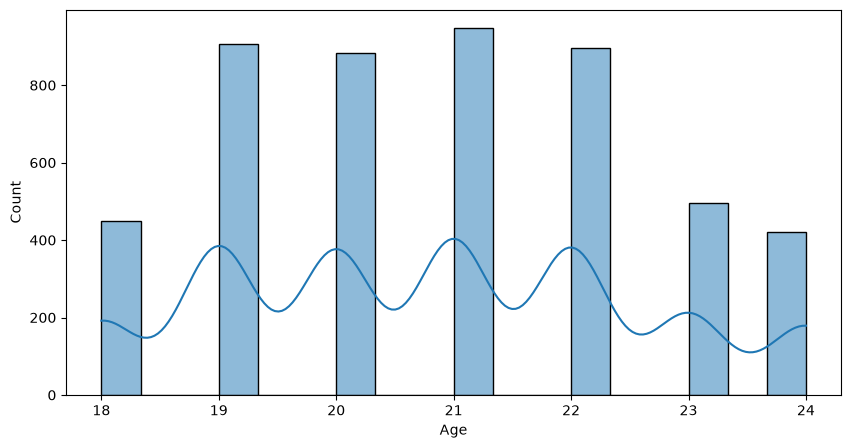

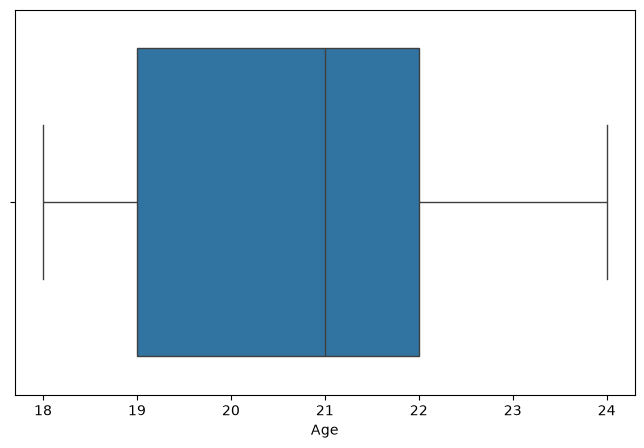

In [5]:
#univarite analysis of Age 
print("skew:",df["Age"].skew()) # dataset is very less skewed 0.15
print(df["Age"].value_counts(ascending=False))
print(df[["Age","Mental_Health_Score"]].corr())
# histogram+kde plot 
plt.figure(figsize=(10,5))
sns.histplot(data=df,x="Age",kde=True)

#boxplot 
plt.figure(figsize=(8,5))
sns.boxplot(data = df ,x= "Age")


In [6]:
# univarite Analysis of Gender 
print(df["Gender"].value_counts()) 

Gender
Male      2635
Female    2365
Name: count, dtype: int64


Country
Other          1880
India           389
USA             355
Canada          230
Australia       198
UK              185
Germany         136
Turkey           94
Mexico           94
France           87
Spain            83
Ireland          81
Japan            77
Denmark          77
Switzerland      73
Nepal            72
Italy            67
Russia           66
Sri Lanka        59
Maldives         57
Name: count, dtype: int64
['Other' 'Canada' 'USA' 'India' 'Australia' 'UK' 'Germany' 'Bangladesh'
 'Brazil' 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia'
 'China' 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panam

<Axes: xlabel='Country', ylabel='count'>

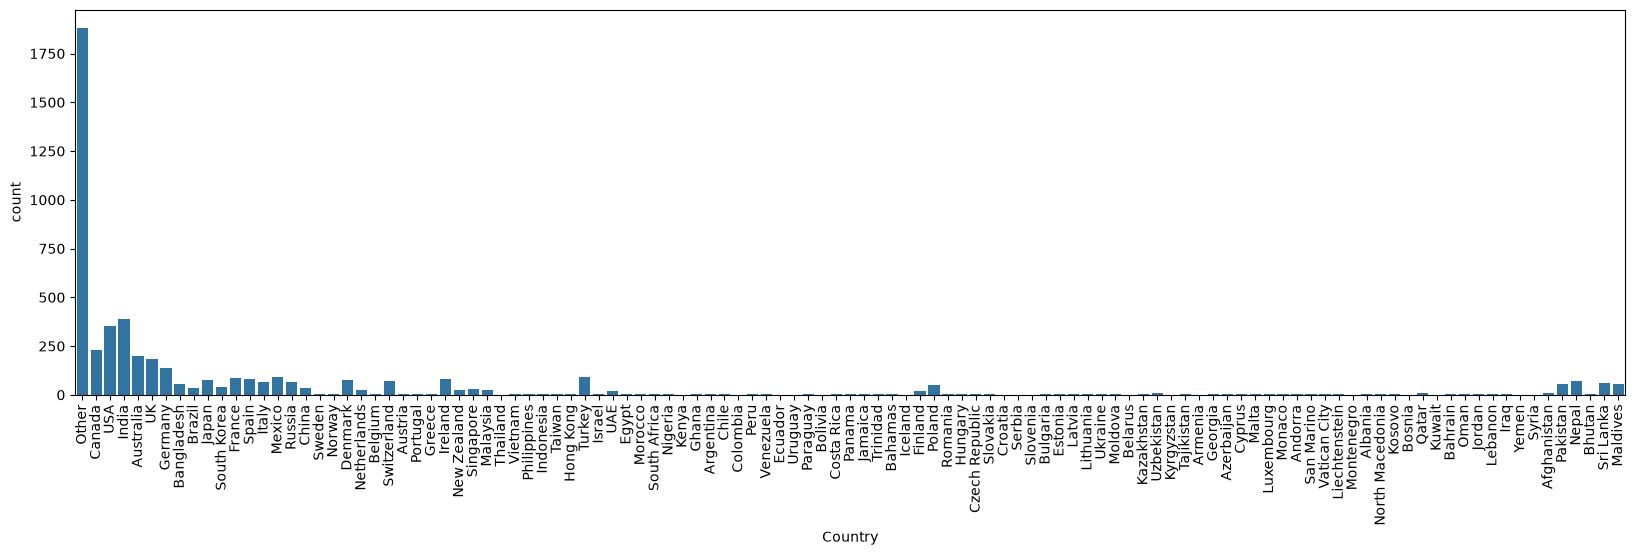

In [7]:
# univarite Analysis of Country
print(df["Country"].value_counts(ascending=False).head(20))
print(df["Country"].unique())
print("nunique:",df["Country"].nunique())


# countplot 
plt.figure(figsize=(20,5))
plt.xticks(rotation=90)
sns.countplot(data=df,x="Country")

In [8]:
print(df["Country"].value_counts()[df["Country"].value_counts() < 10])
country_counts = df["Country"].value_counts()
rare_countries = country_counts[country_counts < 50]
print("Rare country categories:", len(rare_countries))
print("Students in rare categories:", rare_countries.sum())
print("Percentage of students:", round(rare_countries.sum() / len(df) * 100, 2))

Country
Uzbekistan     8
Afghanistan    8
Qatar          7
Sweden         6
Norway         6
              ..
Armenia        1
Kuwait         1
Colombia       1
Bosnia         1
Croatia        1
Name: count, Length: 79, dtype: int64
Rare country categories: 88
Students in rare categories: 484
Percentage of students: 9.68


['Undergraduate' 'Graduate' 'High School']
Academic_Level
Undergraduate    3632
Graduate          918
High School       450
Name: count, dtype: int64


<Axes: xlabel='Academic_Level', ylabel='Mental_Health_Score'>

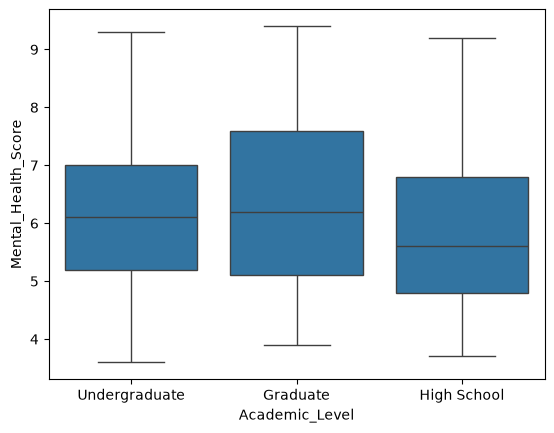

In [9]:
# univarite Analysis of Academic level 
print(df["Academic_Level"].unique()) 
print(df["Academic_Level"].value_counts(ascending=False))

#boxplot
sns.boxplot(data=df,x="Academic_Level",y="Mental_Health_Score")

['Facebook' 'LinkedIn' 'Instagram' 'Snapchat' 'Twitter' 'YouTube' 'TikTok'
 'LINE' 'KakaoTalk' 'VKontakte' 'WhatsApp' 'WeChat']
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64


<Axes: xlabel='Most_Used_Platform', ylabel='Mental_Health_Score'>

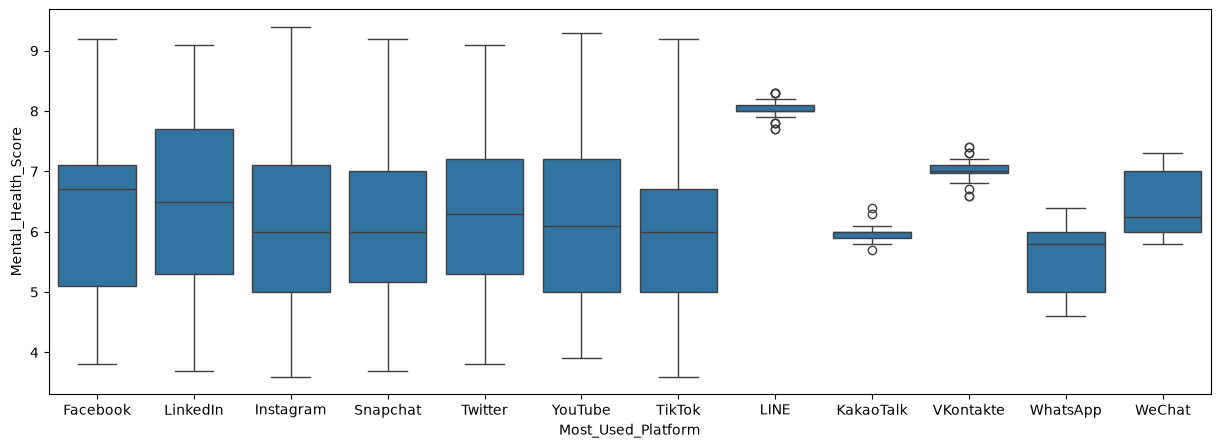

In [10]:
# univariate analysis of Most_Used_Platform 
print(df["Most_Used_Platform"].unique()) 
print(df["Most_Used_Platform"].value_counts(ascending=False))

# boxplot 
plt.figure(figsize=(15,5))
sns.boxplot(data=df,x="Most_Used_Platform",y="Mental_Health_Score")

['Networking' 'Education' 'Entertainment' 'News']
Purpose_Of_Use
Entertainment    2552
Education        1094
Networking        793
News              561
Name: count, dtype: int64


<Axes: xlabel='Purpose_Of_Use', ylabel='Mental_Health_Score'>

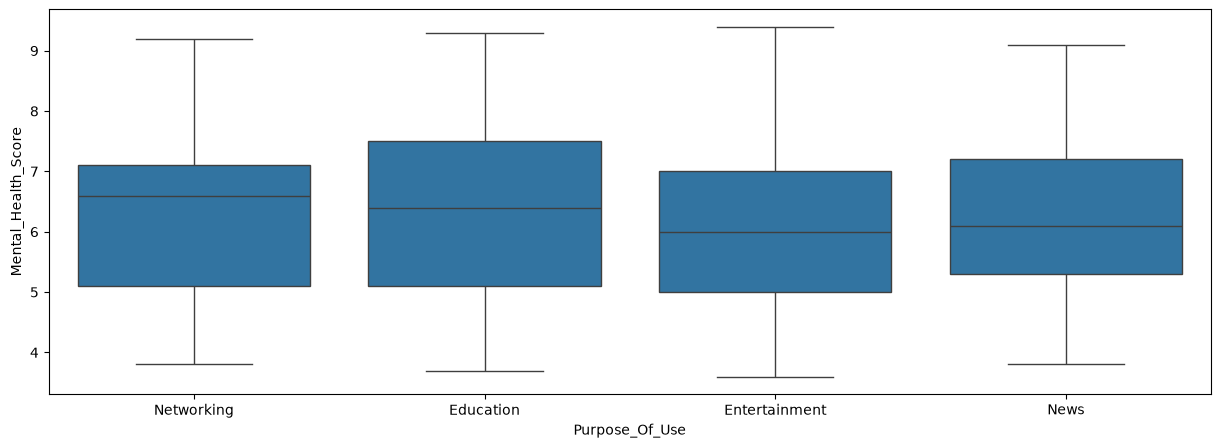

In [11]:
# univariate analysis of Purpose_Of_Use 
print(df["Purpose_Of_Use"].unique()) 
print(df["Purpose_Of_Use"].value_counts(ascending=False))

# boxplot 
plt.figure(figsize=(15,5))
sns.boxplot(data=df,x="Purpose_Of_Use",y="Mental_Health_Score")

0.00560613955389822
                       Avg_Daily_Usage_Hours  Mental_Health_Score
Avg_Daily_Usage_Hours               1.000000            -0.816453
Mental_Health_Score                -0.816453             1.000000


<Axes: xlabel='Avg_Daily_Usage_Hours'>

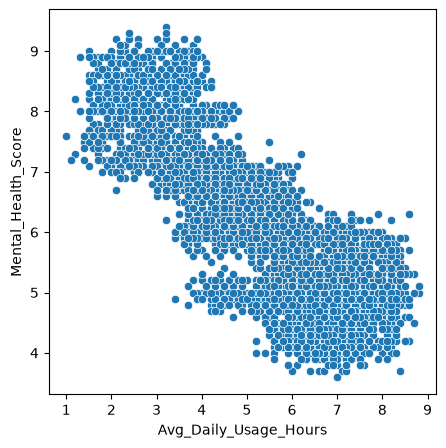

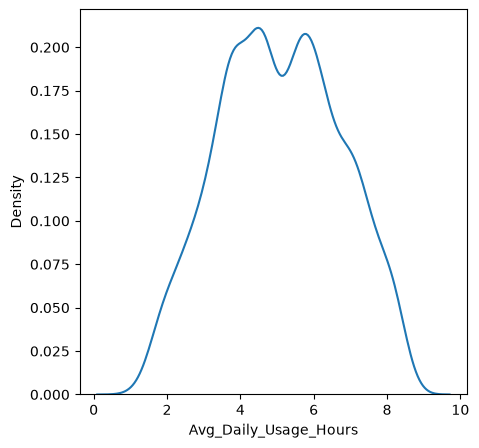

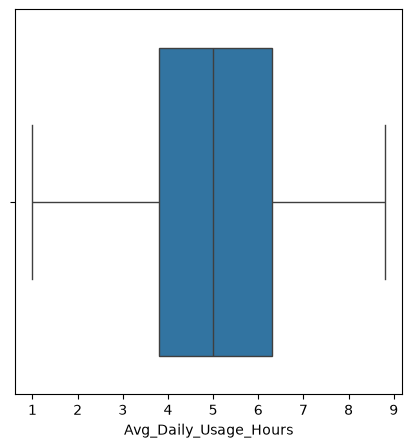

In [12]:
# univarite analysis of Avg_Daily_Usage_Hours 
print(df["Avg_Daily_Usage_Hours"].skew()) 
print(df[["Avg_Daily_Usage_Hours","Mental_Health_Score"]].corr())

# scatterplot 
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x="Avg_Daily_Usage_Hours",y="Mental_Health_Score")

#kde plot 
plt.figure(figsize=(5,5))
sns.kdeplot(data=df,x="Avg_Daily_Usage_Hours")

# boxplot 
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x="Avg_Daily_Usage_Hours")

0.002351349938582424
                     Daily_Unlocks  Mental_Health_Score
Daily_Unlocks             1.000000            -0.790851
Mental_Health_Score      -0.790851             1.000000


<Axes: xlabel='Daily_Unlocks'>

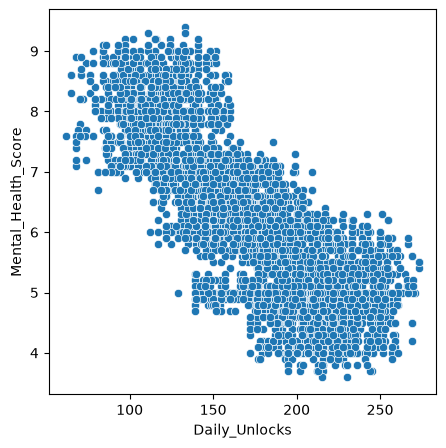

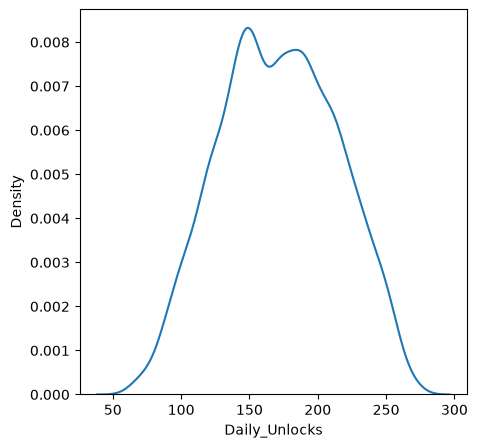

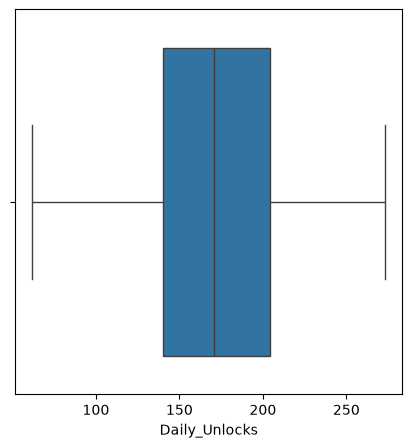

In [13]:
# univarite analysis of Daily_Unlocks 
print(df["Daily_Unlocks"].skew()) 
print(df[["Daily_Unlocks","Mental_Health_Score"]].corr())

# scatterplot 
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x="Daily_Unlocks",y="Mental_Health_Score")

#kde plot 
plt.figure(figsize=(5,5))
sns.kdeplot(data=df,x="Daily_Unlocks")

# boxplot 
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x="Daily_Unlocks")

0.4358185156222703
                     Study_Hours  Mental_Health_Score
Study_Hours             1.000000             0.752626
Mental_Health_Score     0.752626             1.000000


<Axes: xlabel='Study_Hours'>

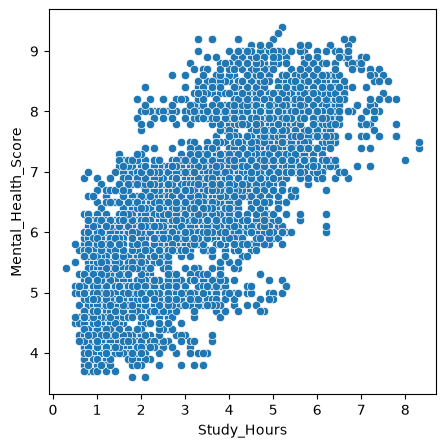

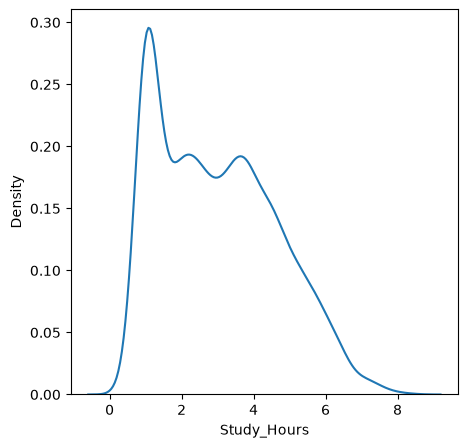

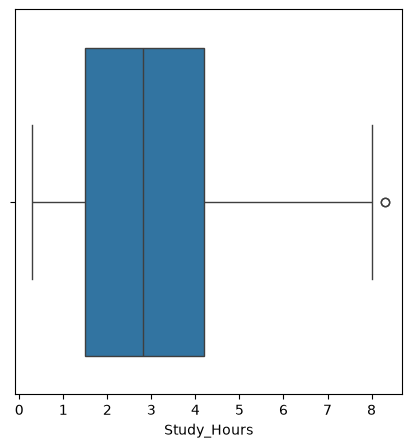

In [14]:
# univarite analysis of Study_Hours 
print(df["Study_Hours"].skew()) 
print(df[["Study_Hours","Mental_Health_Score"]].corr())

# scatterplot 
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x="Study_Hours",y="Mental_Health_Score")

#kde plot 
plt.figure(figsize=(5,5))
sns.kdeplot(data=df,x="Study_Hours")

# boxplot 
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x="Study_Hours")

0.0399705642623147
                         Physical_Activity_Hours  Mental_Health_Score
Physical_Activity_Hours                 1.000000             0.521374
Mental_Health_Score                     0.521374             1.000000


<Axes: xlabel='Physical_Activity_Hours'>

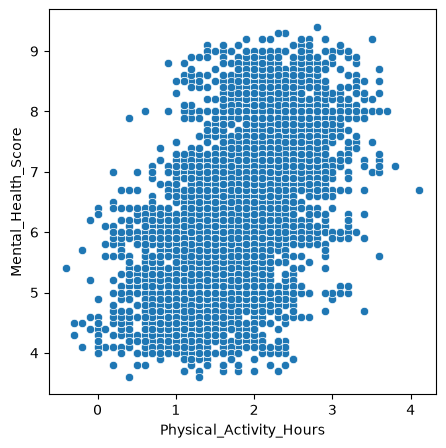

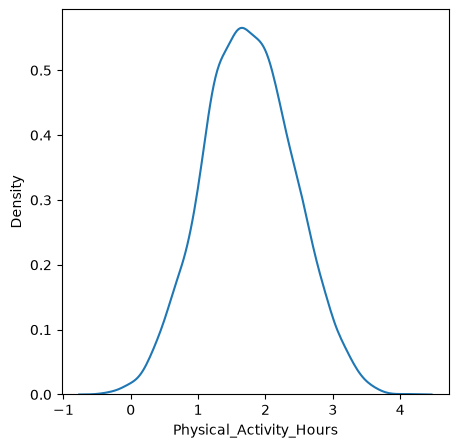

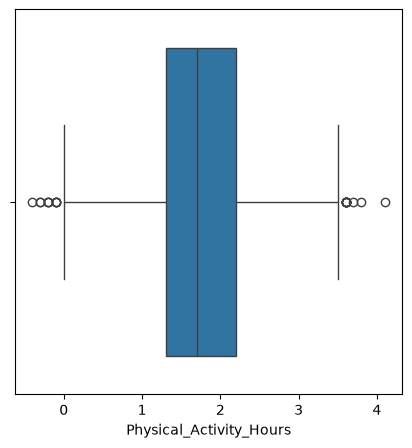

In [15]:
# univarite analysis of Physical_Activity_Hours 
print(df["Physical_Activity_Hours"].skew()) 
print(df[["Physical_Activity_Hours","Mental_Health_Score"]].corr())

# scatterplot 
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x="Physical_Activity_Hours",y="Mental_Health_Score")

#kde plot 
plt.figure(figsize=(5,5))
sns.kdeplot(data=df,x="Physical_Activity_Hours")

# boxplot 
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x="Physical_Activity_Hours")

0.12404965689127949
                       Sleep_Hours_Per_Night  Mental_Health_Score
Sleep_Hours_Per_Night                1.00000              0.76643
Mental_Health_Score                  0.76643              1.00000


<Axes: xlabel='Sleep_Hours_Per_Night'>

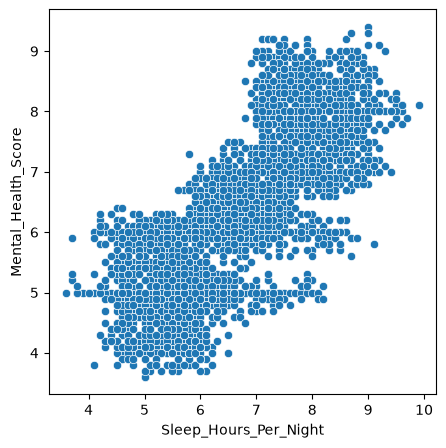

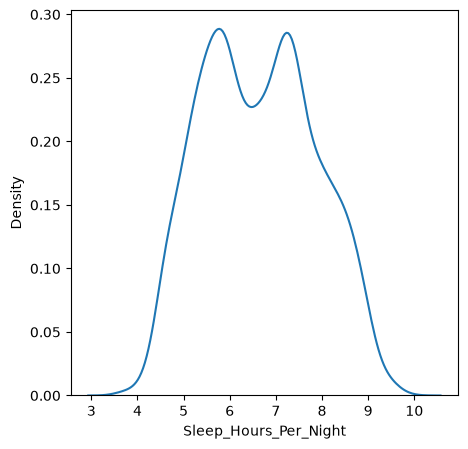

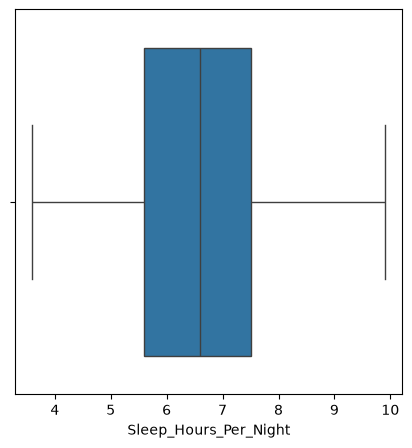

In [16]:
# univarite analysis of Sleep_Hours_Per_Night 
print(df["Sleep_Hours_Per_Night"].skew()) 
print(df[["Sleep_Hours_Per_Night","Mental_Health_Score"]].corr())

# scatterplot 
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x="Sleep_Hours_Per_Night",y="Mental_Health_Score")

#kde plot 
plt.figure(figsize=(5,5))
sns.kdeplot(data=df,x="Sleep_Hours_Per_Night")

# boxplot 
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x="Sleep_Hours_Per_Night")

['Medium' 'Low' 'Very High' 'High']
Stress_Level
Very High    1621
High         1440
Medium       1295
Low           644
Name: count, dtype: int64


<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

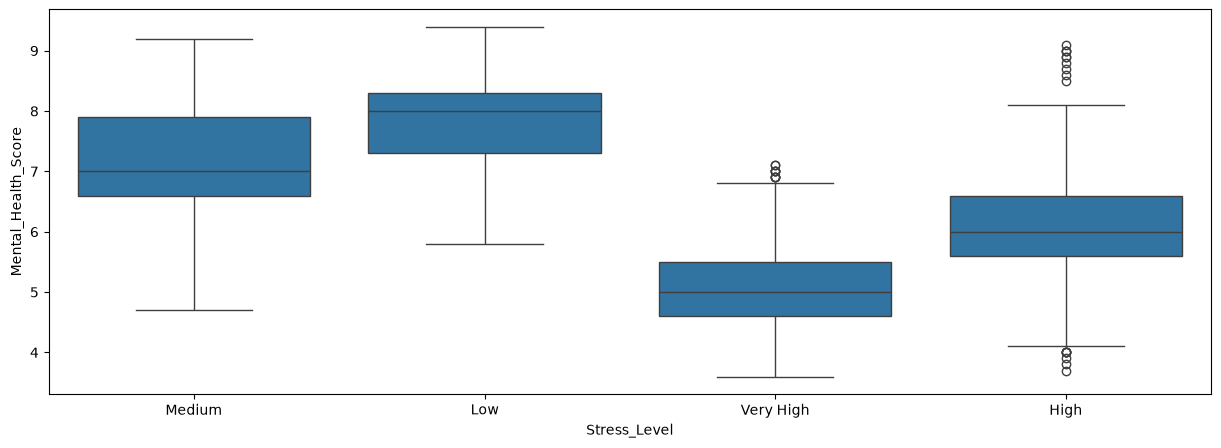

In [17]:
#univariate analysis of Stress_Level 
print(df["Stress_Level"].unique())
print(df["Stress_Level"].value_counts())

# boxplot 
plt.figure(figsize=(15,5))
sns.boxplot(data=df,x="Stress_Level",y="Mental_Health_Score")

0.2065673061644126
                     Mental_Health_Score  Mental_Health_Score
Mental_Health_Score                  1.0                  1.0
Mental_Health_Score                  1.0                  1.0


<Axes: xlabel='Mental_Health_Score'>

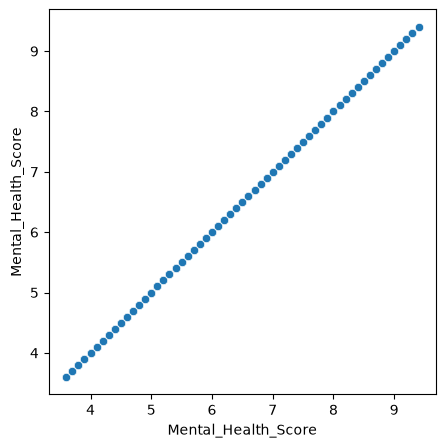

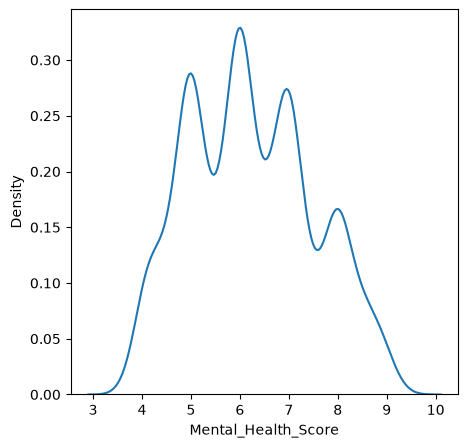

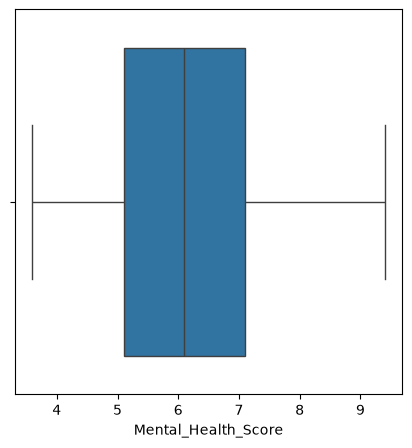

In [18]:
# univarite analysis of Mental_Health_Score 
print(df["Mental_Health_Score"].skew()) 
print(df[["Mental_Health_Score","Mental_Health_Score"]].corr())

# scatterplot 
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x="Mental_Health_Score",y="Mental_Health_Score")

#kde plot 
plt.figure(figsize=(5,5))
sns.kdeplot(data=df,x="Mental_Health_Score")

# boxplot 
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x="Mental_Health_Score")

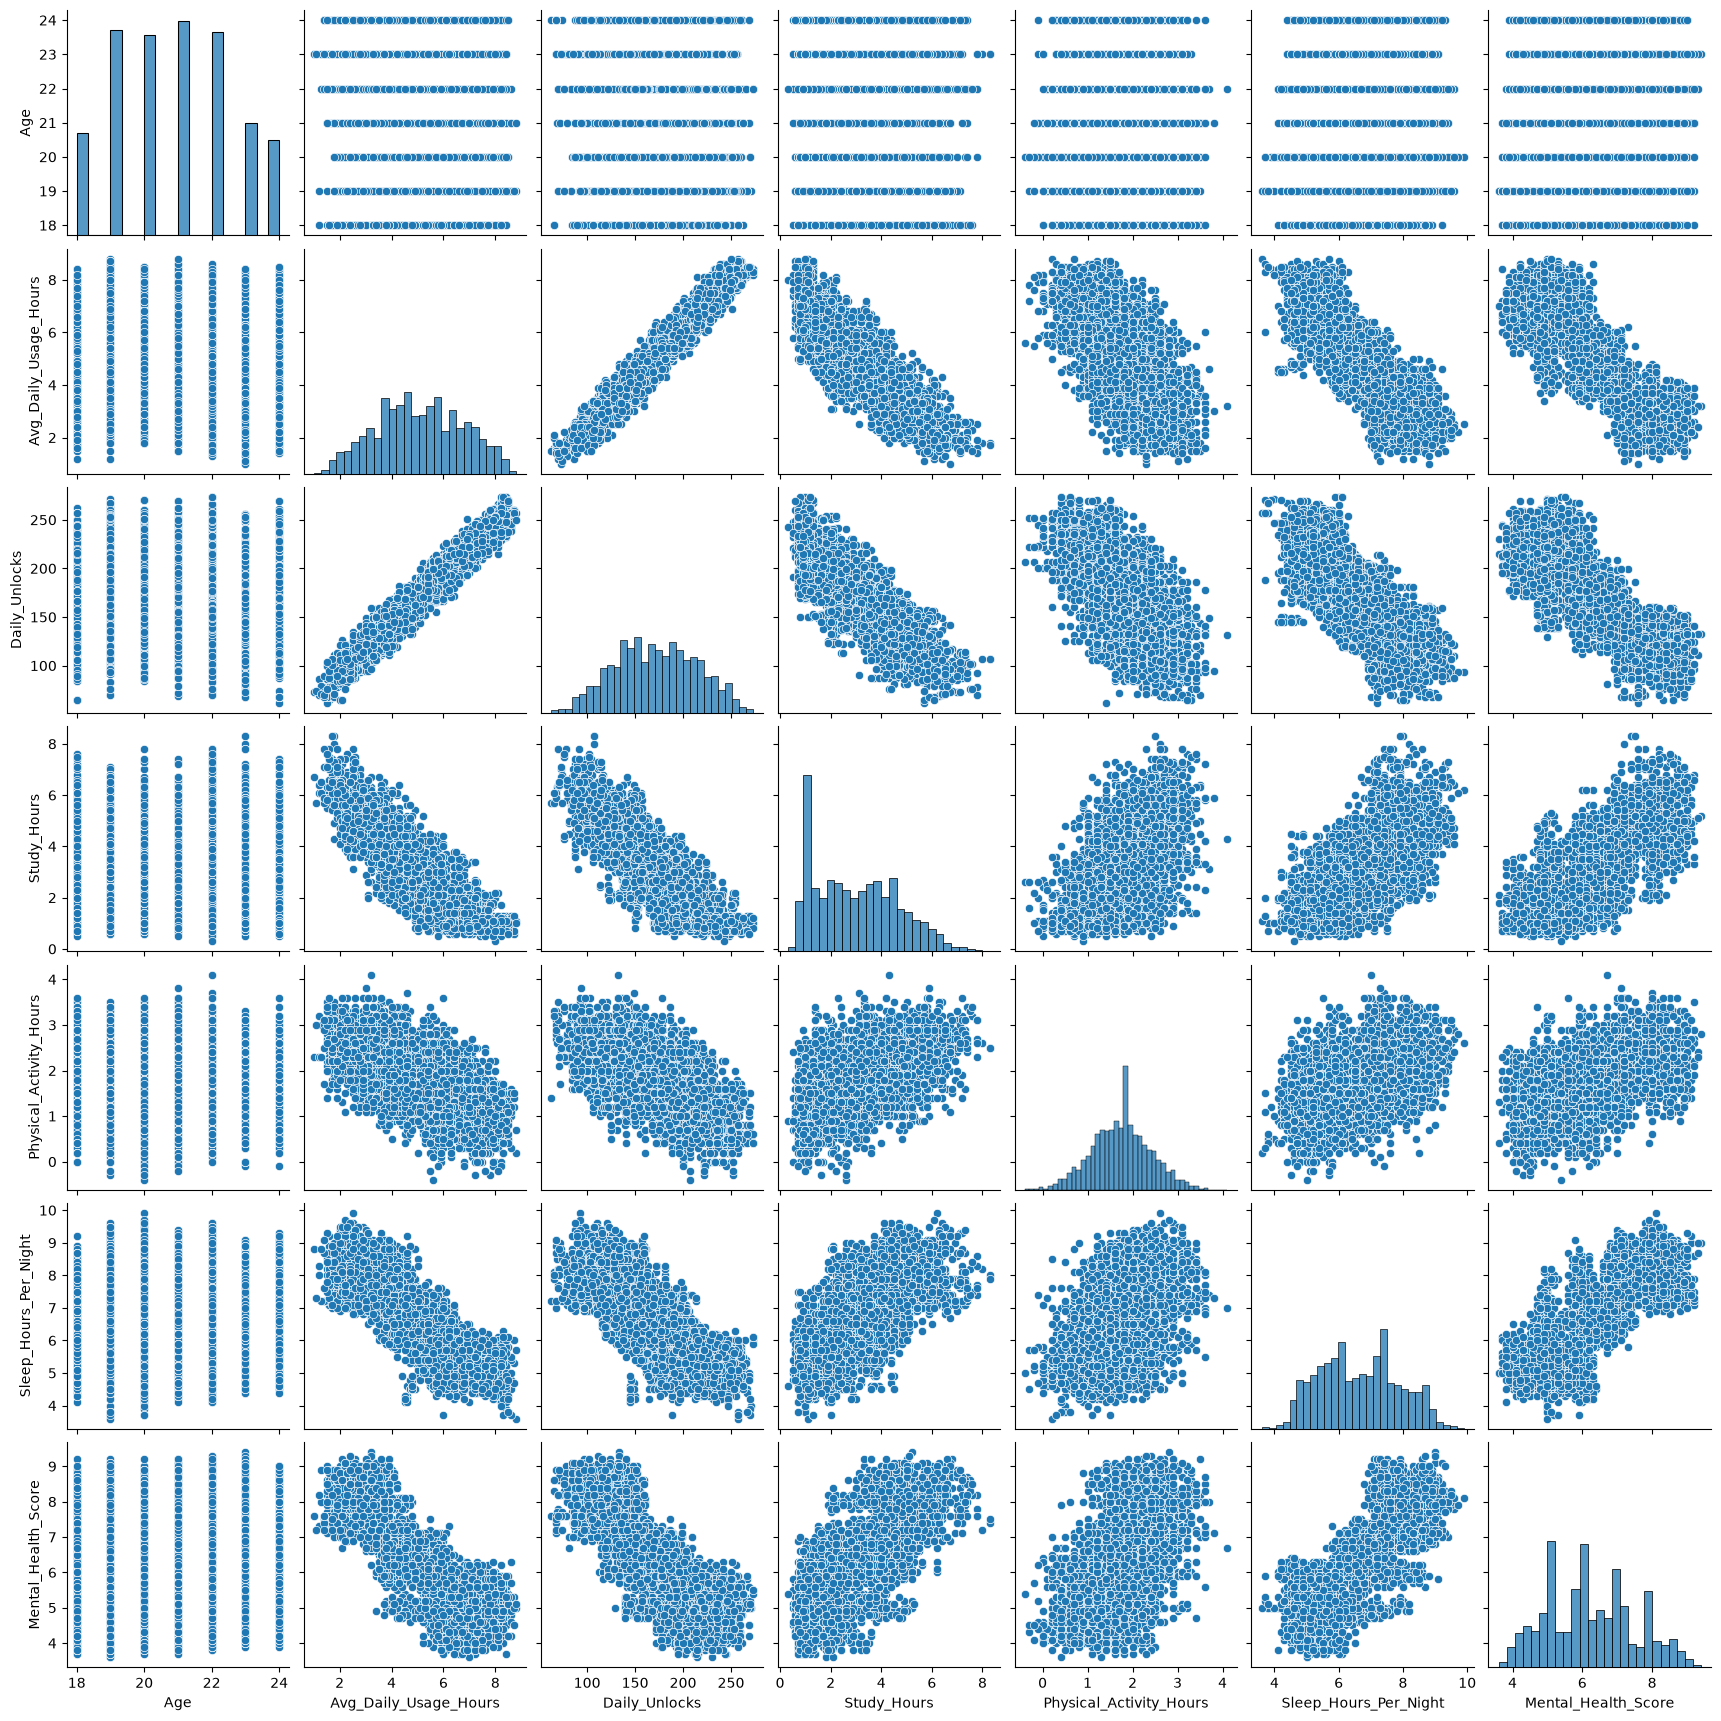

In [19]:
#multivariate analysis 
df.corr(numeric_only=True)
sns.pairplot(df)

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[[
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Study_Hours",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night"
]]

X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

                   Feature         VIF
0                    const  451.730839
1                      Age    1.011856
2    Avg_Daily_Usage_Hours   17.212591
3            Daily_Unlocks   12.899885
4              Study_Hours    4.441469
5  Physical_Activity_Hours    1.647697
6    Sleep_Hours_Per_Night    2.910454


In [21]:
# data cleaning

# drop duplicates 
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [22]:
df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)

In [23]:
# feature trasnformation 
# high cardinality
df["Country"].value_counts(ascending=False).head(11).index

Index(['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany',
       'Turkey', 'Mexico', 'France', 'Spain'],
      dtype='object', name='Country')

In [24]:
def group_countries(data):
    if data in ['India', 'USA', 'Canada', 'Australia', 'UK', 'Germany','Turkey', 'Mexico', 'France', 'Spain']: 
        return data 
    else: 
        return "Other" 

df["Country"] = df["Country"].apply(group_countries)

In [25]:
df["Country"].value_counts()

Country
Other        3148
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Spain          83
Name: count, dtype: int64

In [26]:
#high multicollinearity column drop 
df.drop(columns=["Daily_Unlocks"],inplace=True)

In [27]:
# data preprocessing

X=df.drop(columns=["Mental_Health_Score"])
y = df["Mental_Health_Score"]

#train test split 
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)

In [28]:
numerical_columns = ['Age','Avg_Daily_Usage_Hours','Study_Hours','Physical_Activity_Hours','Sleep_Hours_Per_Night']
categorical_columns = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform','Purpose_Of_Use','Stress_Level']

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder 

transformer = ColumnTransformer([
    ("scaler",StandardScaler(),numerical_columns),
    ("ordinal_Academic_Level",OrdinalEncoder(categories=[['High School','Undergraduate','Graduate']]),['Academic_Level']),
    ("ordinal_Stress_Level",OrdinalEncoder(categories=[['Low','Medium','High','Very High']]),['Stress_Level']),
    ("ohe_encoding",OneHotEncoder(drop="first",sparse_output=False),['Gender', 'Country', 'Most_Used_Platform','Purpose_Of_Use'])   
])

In [30]:
from sklearn.linear_model import LinearRegression 
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("transformation",transformer), 
    ("linearmodel",LinearRegression())]
)

rf_pipeline = Pipeline([
    ("transformation",transformer), 
    ("rfmodel",RandomForestRegressor())]
)

In [31]:
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_test)

In [32]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))

MAE : 0.5288328757043714
RMSE: 0.6734807497064038
R²  : 0.7459252481654017


In [33]:
rf_pipeline.fit(X_train,y_train)
rf_y_pred = rf_pipeline.predict(X_test)

In [34]:
print("MAE :", mean_absolute_error(y_test, rf_y_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_y_pred))
print("R²  :", r2_score(y_test, rf_y_pred))

MAE : 0.3487405000000001
RMSE: 0.47374161179909036
R²  : 0.8742829437044473


In [ ]:
from sklearn.model_selection import RandomizedSearchCV 

param_grid = {
    "rfmodel__n_estimators": [100, 200, 300, 500],
    "rfmodel__max_depth": [None, 5, 10, 15, 20, 30],
    "rfmodel__min_samples_split": [2, 5, 10],
    "rfmodel__min_samples_leaf": [1, 2, 4],
    "rfmodel__max_features": [1.0, "sqrt", "log2"],
    "rfmodel__bootstrap": [True, False]
}

rscv = RandomizedSearchCV(estimator=rf_pipeline,cv=5,random_state=42,n_iter=30,param_distributions=param_grid,scoring="neg_root_mean_squared_error")
rscv.fit(X_train,y_train)

In [ ]:
best_model = rscv.best_estimator_ 
best_y_pred = best_model.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, best_y_pred))
print("RMSE:", root_mean_squared_error(y_test, best_y_pred))
print("R²  :", r2_score(y_test, best_y_pred))

In [ ]:
import joblib 
joblib.dump(best_model,"model.joblib")